# SMS Spam Classification with PySpark in Google Colab

## MSc Big Data Lab

This lab shows how to build an end-to-end **text classification pipeline** in **PySpark** using the **SMS Spam Collection** dataset.

### Learning outcomes
By the end of this lab, you should be able to:

1. load a text dataset into Spark
2. inspect and clean text data
3. build a Spark ML pipeline for text classification
4. convert text into **TF-IDF** features
5. train a **Multinomial Naive Bayes** classifier
6. evaluate the classifier using:
   - accuracy
   - precision
   - recall
   - F1-score
   - ROC-AUC
7. interpret outputs using visualisations
8. improve the model using **hyperparameter tuning**

### Dataset
This notebook expects the file:

`SMSSpamCollection`

It contains two tab-separated columns:
- **label**: `ham` or `spam`
- **message**: SMS text

---

## Step 0 — Install required packages

Run the next cell to install the required Python libraries in Colab.

In [75]:
from jupyter_core.application import base_flags
!pip install pyspark nltk wordcloud scikit-learn -q


[notice] A new release of pip is available: 24.3.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


## Step 1 — Import libraries and start Spark

This section imports all required libraries and creates a Spark session.

### Libraries used
- **PySpark** for distributed data processing and machine learning
- **NLTK** for stop words
- **matplotlib** for visualisations
- **wordcloud** for word cloud plots
- **scikit-learn** for confusion matrix and ROC utilities

In [76]:
import nltk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from wordcloud import WordCloud
from sklearn.metrics import confusion_matrix, roc_curve, auc

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.ml import Pipeline
from pyspark.ml.feature import (
    StringIndexer,
    RegexTokenizer,
    StopWordsRemover,
    CountVectorizer,
    IDF
)
from pyspark.ml.classification import NaiveBayes
from pyspark.ml.evaluation import (
    MulticlassClassificationEvaluator,
    BinaryClassificationEvaluator
)
from pyspark.ml.functions import vector_to_array
from pyspark.ml.tuning import ParamGridBuilder, TrainValidationSplit

nltk.download("stopwords")
plt.style.use("ggplot")

spark = SparkSession.builder.appName("SMS_Spam_Classification_Lab").getOrCreate()
print("Spark session created successfully.")

Spark session created successfully.


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/wizrdm/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Step 2 — Upload the dataset

Run the next cell and upload the file `SMSSpamCollection`.



In [77]:
# from google.colab import files

print("Please upload the SMSSpamCollection file.")
# uploaded = files.upload()
# file_name = list(uploaded.keys())[0]
file_path = '/Users/wizrdm/Desktop/UEL/Machine Learning on Big Data/SMSSpamCollection.txt'

print("Uploaded file:", file_path)

Please upload the SMSSpamCollection file.
Uploaded file: /Users/wizrdm/Desktop/UEL/Machine Learning on Big Data/SMSSpamCollection.txt


## Step 3 — Load and clean the data

We now load the file into Spark and apply basic cleaning.

### Cleaning steps
- rename columns to `label` and `message`
- convert labels to lowercase
- trim whitespace
- keep only valid labels: `ham` and `spam`
- remove empty messages

In [78]:
raw = (
    spark.read
    .option("sep", "\t")
    .option("inferSchema", "false")
    .csv(file_path)
    .toDF("label", "message")
)

df = (
    raw
    .withColumn("label", F.lower(F.trim(F.col("label"))))
    .withColumn("message", F.trim(F.col("message")))
    .filter(F.col("label").isin(["ham", "spam"]))
    .filter(F.col("message").isNotNull())
    .filter(F.length(F.col("message")) > 0)
)

print("Rows after cleaning:", df.count())
df.show(5, truncate=False)

Rows after cleaning: 5574
+-----+-----------------------------------------------------------------------------------------------------------------------------------------------------------+
|label|message                                                                                                                                                    |
+-----+-----------------------------------------------------------------------------------------------------------------------------------------------------------+
|ham  |Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...                                            |
|ham  |Ok lar... Joking wif u oni...                                                                                                                              |
|spam |Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075

## Step 4 — Understand the data

Before building a model, we explore the dataset.

We will check:
1. class balance
2. sample messages
3. message length distribution

In [79]:
print("Class distribution:")
df.groupBy("label").count().orderBy(F.desc("count")).show()

print("Sample rows:")
df.show(10, truncate=False)

df = df.withColumn("message_length", F.length(F.col("message")))

Class distribution:
+-----+-----+
|label|count|
+-----+-----+
|  ham| 4827|
| spam|  747|
+-----+-----+

Sample rows:
+-----+----------------------------------------------------------------------------------------------------------------------------------------------------------------+
|label|message                                                                                                                                                         |
+-----+----------------------------------------------------------------------------------------------------------------------------------------------------------------+
|ham  |Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...                                                 |
|ham  |Ok lar... Joking wif u oni...                                                                                                                                   |
|spam |Free entry in 2 a wkly comp to

## Step 5 — Visualise the dataset

### Visual 1: Class distribution
This shows whether the dataset is balanced or imbalanced.

### Visual 2: Message length distribution
This compares the lengths of ham and spam messages.

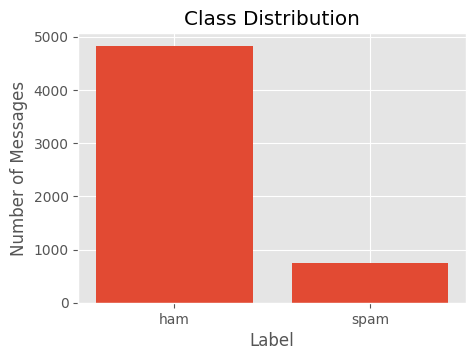

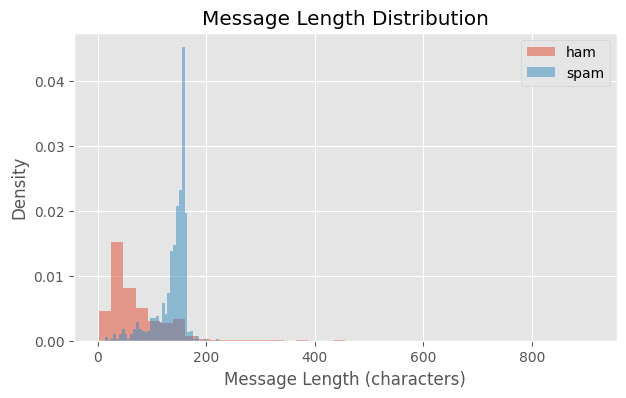

In [80]:
# Class distribution
balance_pd = df.groupBy("label").count().toPandas()

plt.figure(figsize=(5, 3.5))
plt.bar(balance_pd["label"], balance_pd["count"])
plt.title("Class Distribution")
plt.xlabel("Label")
plt.ylabel("Number of Messages")
plt.show()

# Message length distribution
length_pd = df.select("label", "message_length").toPandas()

plt.figure(figsize=(7, 4))
for lab in ["ham", "spam"]:
    subset = length_pd[length_pd["label"] == lab]["message_length"]
    plt.hist(subset, bins=40, alpha=0.5, density=True, label=lab)

plt.title("Message Length Distribution")
plt.xlabel("Message Length (characters)")
plt.ylabel("Density")
plt.legend()
plt.show()

## Step 6 — Build the Spark ML Pipeline

A Spark ML pipeline lets us combine preprocessing and model training in a clean, reusable workflow.

### Step 6 — Build the Spark ML Pipeline

| Stage | Class | Purpose |
|---|---|---|
| 1 | `StringIndexer` | Convert `ham` / `spam` into numeric labels |
| 2 | `RegexTokenizer` | Split each message into tokens |
| 3 | `StopWordsRemover` | Remove common English stop words |
| 4 | `CountVectorizer` | Convert tokens into term-frequency vectors |
| 5 | `IDF` | Apply inverse document frequency weighting |
| 6 | `NaiveBayes` | Train a multinomial Naive Bayes classifier |

### Why this pipeline?
This is a standard and strong baseline for text classification:
- `CountVectorizer` captures term frequency
- `IDF` reduces the weight of very common words
- `NaiveBayes` is fast and effective for sparse text data

In [81]:
label_indexer = StringIndexer(inputCol="label", outputCol="label_num")

tokenizer = RegexTokenizer(
    inputCol="message",
    outputCol="tokens",
    pattern="\\W+",
    toLowercase=True
)

remover = StopWordsRemover(
    inputCol="tokens",
    outputCol="filtered_tokens"
)

cv = CountVectorizer(
    inputCol="filtered_tokens",
    outputCol="tf_features",
    vocabSize=10000,
    minDF=1
)

idf = IDF(
    inputCol="tf_features",
    outputCol="features"
)

nb = NaiveBayes(
    featuresCol="features",
    labelCol="label_num",
    modelType="multinomial",
    smoothing=1.0
)

pipeline = Pipeline(stages=[
    label_indexer,
    tokenizer,
    remover,
    cv,
    idf,
    nb
])

print("Pipeline created successfully.")

Pipeline created successfully.


## Step 7 — Split the dataset into training and testing sets

We now divide the data into:
- **80% training data**
- **20% testing data**

The model learns from the training set and is evaluated on the test set.

In [82]:
train_df, test_df = df.randomSplit([0.8, 0.2], seed=42)

print("Training records:", train_df.count())
print("Testing records :", test_df.count())

Training records: 4503
Testing records : 1071


## Step 8 — Train the model

We now fit the pipeline on the training dataset.

After training, the pipeline contains:
- a fitted label indexer
- a fitted vectorizer
- a fitted IDF model
- a trained Naive Bayes classifier

In [83]:
base_model = pipeline.fit(train_df)
base_pred = base_model.transform(test_df)

print("Model trained successfully.")
base_pred.select("label", "label_num", "prediction", "probability", "message").show(10, truncate=False)

Model trained successfully.
+-----+---------+----------+-------------------------------------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------+
|label|label_num|prediction|probability                                |message                                                                                                                                                    |
+-----+---------+----------+-------------------------------------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------+
|ham  |0.0      |0.0       |[1.0,3.799463137417947E-55]                |"Its Ur luck to Love someone. Its Ur fortune to Love the one who Loves U. But, its a miracle to Love a person who can't Love anyone except U..." Gud nyt...|
|ham  |0.0      |0.0       |[1.0,3.8403679519194456E-48]

## Step 9 — Understand label mapping

Spark converts text labels into numeric labels.

We inspect the fitted `StringIndexer` so we know which number corresponds to:
- `ham`
- `spam`

This is important for evaluation and ROC analysis.

In [84]:
label_model = base_model.stages[0]
print("Label mapping:")
for i, lab in enumerate(label_model.labels):
    print(f"{i} -> {lab}")

spam_index = int(label_model.labels.index("spam"))
ham_index = int(label_model.labels.index("ham"))

print("Spam index:", spam_index)
print("Ham index :", ham_index)

Label mapping:
0 -> ham
1 -> spam
Spam index: 1
Ham index : 0


## Step 10 — Evaluate the model

We calculate four standard classification metrics:

- **Accuracy**: overall proportion predicted correctly
- **Precision**: how many predicted spam messages were truly spam
- **Recall**: how many actual spam messages were found
- **F1-score**: balance between precision and recall

In [85]:
metrics = {}
for metric_name in ["accuracy", "weightedPrecision", "weightedRecall", "f1"]:
    evaluator = MulticlassClassificationEvaluator(
        labelCol="label_num",
        predictionCol="prediction",
        metricName=metric_name
    )
    metrics[metric_name] = evaluator.evaluate(base_pred)

print("Evaluation metrics:")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

Evaluation metrics:
accuracy: 0.9767
weightedPrecision: 0.9773
weightedRecall: 0.9767
f1: 0.9769


## Step 11 — Build the confusion matrix

A confusion matrix helps us understand the types of mistakes the classifier makes.

It shows:
- true ham predicted as ham
- true ham predicted as spam
- true spam predicted as ham
- true spam predicted as spam

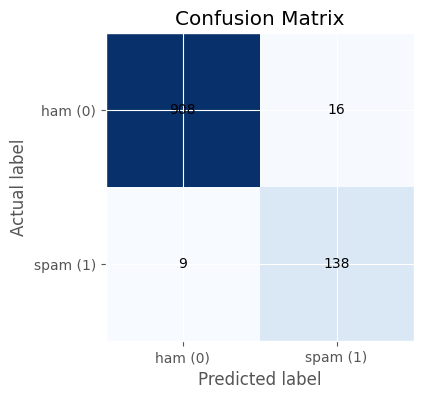

In [86]:
cm_pd = base_pred.select("label_num", "prediction").toPandas()

cm = confusion_matrix(cm_pd["label_num"], cm_pd["prediction"])

classes = [f"{lbl} ({i})" for i, lbl in enumerate(label_model.labels)]

plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap="Blues")

for (i, j), value in np.ndenumerate(cm):
    plt.text(j, i, int(value), ha="center", va="center", color="black")

plt.xticks(range(len(classes)), classes)
plt.yticks(range(len(classes)), classes)
plt.xlabel("Predicted label")
plt.ylabel("Actual label")
plt.title("Confusion Matrix")
plt.show()

## Step 12 — Compute ROC curve and AUC

For ROC analysis, we need the probability assigned to the **spam** class.

### Why use ROC-AUC?
ROC-AUC measures ranking quality across thresholds:
- closer to **1.0** is better
- **0.5** is roughly random guessing

ROC-AUC: 0.9895


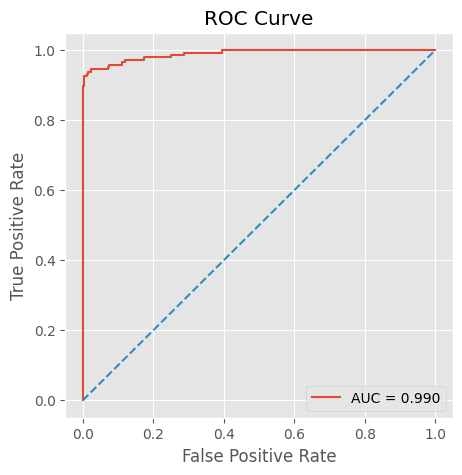

In [87]:
base_pred = (
    base_pred
    .withColumn("prob_arr", vector_to_array(F.col("probability")))
    .withColumn("spamProb", F.col("prob_arr")[spam_index])
)

base_roc_pd = base_pred.select("label_num", "spamProb").toPandas()

fpr, tpr, thresholds = roc_curve(base_roc_pd["label_num"], base_roc_pd["spamProb"])
base_roc_auc = auc(fpr, tpr)

print(f"ROC-AUC: {base_roc_auc:.4f}")

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"AUC = {base_roc_auc:.3f}")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## Step 13 — Inspect confident spam predictions

This helps students see which messages the model is very confident are spam.

In [88]:
base_pred.select("message", "label", "prediction", "spamProb") \
    .orderBy(F.desc("spamProb")) \
    .show(10, truncate=False)

+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-----+----------+--------+
|message                                                                                                                                                                      |label|prediction|spamProb|
+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-----+----------+--------+
|Camera - You are awarded a SiPix Digital Camera! call 09061221066 fromm landline. Delivery within 28 days                                                                    |spam |1.0       |1.0     |
|Dear Voucher Holder, To claim this weeks offer, at your PC please go to http://www.wtlp.co.uk/text. Ts&Cs apply.                                                             |spam |1.0       |

## Step 14 — Inspect misclassified messages

Misclassifications are often the most educational examples.

These are messages where:
- the real label and predicted label are different

In [89]:
base_pred.filter(F.col("label_num") != F.col("prediction")) \
    .select("message", "label", "prediction", "spamProb") \
    .show(15, truncate=False)

+-----------------------------------------------------------------------------------------------------------------------------------------------------------+-----+----------+------------------+
|message                                                                                                                                                    |label|prediction|spamProb          |
+-----------------------------------------------------------------------------------------------------------------------------------------------------------+-----+----------+------------------+
|Did u receive my msg?                                                                                                                                      |ham  |1.0       |0.9999997295929602|
|Don know. I did't msg him recently.                                                                                                                        |ham  |1.0       |0.652344827247367 |
|Hey now am free you can call 

## Step 15 — Word clouds for ham and spam

Word clouds are not a rigorous feature-importance method, but they are useful for intuition.

They help students quickly see:
- common words in ham messages
- common words in spam messages

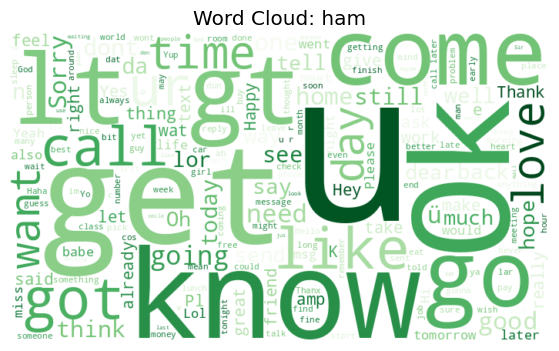

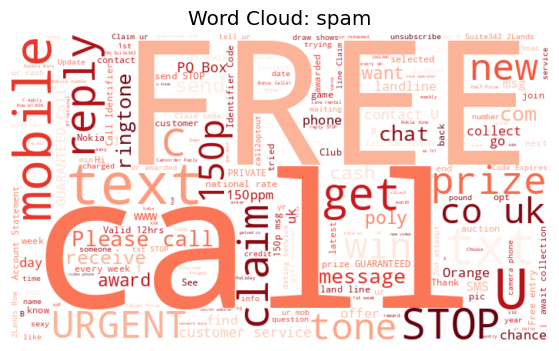

In [90]:
stop_words = set(nltk.corpus.stopwords.words("english"))

def collect_docs(label_value, n=3000):
    return " ".join(
        row["message"]
        for row in df.filter(F.col("label") == label_value).limit(n).collect()
    )

for lab, cmap in [("ham", "Greens"), ("spam", "Reds")]:
    text_blob = collect_docs(lab)
    wc = WordCloud(
        width=700,
        height=400,
        background_color="white",
        stopwords=stop_words,
        colormap=cmap
    ).generate(text_blob)

    plt.figure(figsize=(8, 4))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Word Cloud: {lab}")
    plt.show()

## Step 16 — Hyperparameter tuning with grid search

This is one of the most important extensions in the notebook.

We now search over multiple parameter combinations to improve the model.

### Parameters explored
- `CountVectorizer.vocabSize`
- `NaiveBayes.smoothing`

### Why tune hyperparameters?
A reasonable baseline model is good, but tuning often improves:
- F1-score
- balance between precision and recall
- robustness

In [91]:
param_grid = (
    ParamGridBuilder()
    .addGrid(cv.vocabSize, [2000, 5000, 10000])
    .addGrid(nb.smoothing, [0.5, 1.0, 2.0])
    .build()
)

tune_evaluator = MulticlassClassificationEvaluator(
    labelCol="label_num",
    predictionCol="prediction",
    metricName="f1"
)

tvs = TrainValidationSplit(
    estimator=pipeline,
    estimatorParamMaps=param_grid,
    evaluator=tune_evaluator,
    trainRatio=0.8,
    seed=42
)

tuned_model = tvs.fit(train_df)
tuned_pred = tuned_model.transform(test_df)

print("Grid search completed.")

Grid search completed.


## Step 16.5 — Show validation F1 for every param

Add to confirm validation F1, plus best model settings

In [92]:
# Show validation F1 for every parameter combination tested
tuning_results = []

for params, score in zip(param_grid, tuned_model.validationMetrics):
    tuning_results.append({
        "vocabSize": params[cv.vocabSize],
        "smoothing": params[nb.smoothing],
        "validation_f1": score
    })

tuning_results_df = pd.DataFrame(tuning_results)
tuning_results_df.sort_values("validation_f1", ascending=False)

best_pipeline_model = tuned_model.bestModel

best_cv_model = best_pipeline_model.stages[3]
best_nb_model = best_pipeline_model.stages[-1]

print("Best vocab size:", len(best_cv_model.vocabulary))
print("Best smoothing:", best_nb_model.getSmoothing())

Best vocab size: 7718
Best smoothing: 0.5


## Step 17 — Evaluate the tuned model

We compare the tuned model to the original model using:
- F1-score
- ROC-AUC

In [93]:
tuned_f1 = tune_evaluator.evaluate(tuned_pred)
print(f"Tuned F1-score: {tuned_f1:.4f}")

# bestModel is the fitted PipelineModel
best_pipeline_model = tuned_model.bestModel

# get fitted StringIndexer model from pipeline stages
tuned_label_model = best_pipeline_model.stages[0]
tuned_spam_index = int(tuned_label_model.labels.index("spam"))

tuned_pred = (
    tuned_pred
    .withColumn("prob_arr", vector_to_array(F.col("probability")))
    .withColumn("spamProb", F.col("prob_arr")[tuned_spam_index])
)

tuned_auc_evaluator = BinaryClassificationEvaluator(
    labelCol="label_num",
    rawPredictionCol="spamProb",
    metricName="areaUnderROC"
)

tuned_auc = tuned_auc_evaluator.evaluate(tuned_pred)
print(f"Tuned ROC-AUC: {tuned_auc:.4f}")

Tuned F1-score: 0.9750
Tuned ROC-AUC: 0.9884


## Step 18 — Compare baseline vs tuned results

This final comparison helps students see whether grid search actually improved the model.

In [94]:
baseline_f1 = metrics["f1"]

comparison = pd.DataFrame({
    "Model": ["Baseline", "Tuned"],
    "F1-score": [baseline_f1, tuned_f1],
    "ROC-AUC": [base_roc_auc, tuned_auc]
})

comparison

,Model,F1-score,ROC-AUC
0,Baseline,0.976884,0.989538
1,Tuned,0.975035,0.988360


## Step 19 — Key interpretation points

### What students should notice
1. The dataset is usually **imbalanced**, with more ham than spam.
2. Spam messages are often longer on average.
3. TF-IDF is effective for sparse text classification.
4. Naive Bayes is a strong baseline for text data.
5. Grid search can improve the model, but not always dramatically.
6. Looking at **misclassified messages** is often more useful than just reporting accuracy.



## Step 20 — Student warm up exercises

### Task 1
Change `vocabSize` from `5000` to `10000` in the baseline pipeline and compare results.

### Task 2
Try `minDF=1` and compare the effect.

### Task 3
Remove `StopWordsRemover` and see whether performance changes.

### Task 4
Inspect the top 20 misclassified messages and explain why they were difficult.



## Optional final step

If you want, you can stop the Spark session at the end.

In [95]:
# spark.stop()